**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Input, Sequential
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

**Text preprocessing & Tokenisation**

In [ ]:
df = pd.read_csv("/content/ecommerceDataset.csv", header=None)

In [ ]:
df.columns

Index([0, 1], dtype='int64')

In [ ]:
df.columns = ["label", "text"]
df.head()

,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [ ]:
df.shape

(50425, 2)

In [ ]:
df.nunique()

,0
label,4
text,27802


In [ ]:
df['label'].value_counts()

,count
label,
Household,19313
Books,11820
Electronics,10621
Clothing & Accessories,8671


In [ ]:
df.isnull().sum()

,0
label,0
text,1


In [ ]:
df['text'] = df['text'].fillna("")

In [ ]:
vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])
print(tokenizer.word_index)
sequences = tokenizer.texts_to_sequences(df['text'])

max_len = 200
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df['label'].values

{'<OOV>': 1, 'the': 2, 'and': 3, 'of': 4, 'to': 5, 'a': 6, 'for': 7, 'in': 8, 'with': 9, 'is': 10, 'your': 11, 'you': 12, 'it': 13, 'this': 14, 'on': 15, 'that': 16, 'from': 17, 'or': 18, 'can': 19, 'as': 20, 'are': 21, '1': 22, 'be': 23, 'an': 24, 'all': 25, 'has': 26, '2': 27, 'at': 28, 'by': 29, '3': 30, '5': 31, 'will': 32, 'size': 33, 'book': 34, 'x': 35, 'set': 36, 'use': 37, 'easy': 38, 'quality': 39, 'one': 40, 'up': 41, 'not': 42, 'which': 43, 'about': 44, 'have': 45, 'high': 46, 'also': 47, 'he': 48, 'black': 49, 'product': 50, '4': 51, 'made': 52, 'home': 53, 'design': 54, 'our': 55, 'more': 56, 'author': 57, 'his': 58, 'any': 59, 'its': 60, 'color': 61, 'time': 62, 'power': 63, 'new': 64, 'we': 65, '6': 66, 'cotton': 67, 'these': 68, 'other': 69, 'usb': 70, 'best': 71, 'perfect': 72, 'light': 73, 'comes': 74, 'most': 75, 'make': 76, 'features': 77, 'no': 78, 'so': 79, 'used': 80, 'material': 81, 'when': 82, 'water': 83, '0': 84, 'designed': 85, '\xa0': 86, 'long': 87, 'out'

**Split into train/validation/test**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

**Build the CNN model**

In [ ]:
le = LabelEncoder()
le.fit(df['label'].astype(str).str.strip())

y_train = pd.Series(y_train).astype(str).str.strip().values
y_val   = pd.Series(y_val).astype(str).str.strip().values
y_test  = pd.Series(y_test).astype(str).str.strip().values

y_train = le.transform(y_train).astype('int32')
y_val   = le.transform(y_val).astype('int32')
y_test  = le.transform(y_test).astype('int32')

print("y_train dtype:", y_train.dtype, "unique:", np.unique(y_train))

y_train dtype: int32 unique: [0 1 2 3]


In [ ]:
model = tf.keras.Sequential([
    Input(shape=(max_len,), dtype='int32'),
    layers.Embedding(input_dim=vocab_size, output_dim=128),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=5),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=5),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 35, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,781,764 (10.61 MB)

 Trainable params: 2,781,764 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train the model**

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_val, y_val))

Epoch 1/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 146s 261ms/step - accuracy: 0.7128 - loss: 0.6993 - val_accuracy: 0.9705 - val_loss: 0.1271
Epoch 2/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 139s 252ms/step - accuracy: 0.9817 - loss: 0.0832 - val_accuracy: 0.9746 - val_loss: 0.1087
Epoch 3/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 142s 253ms/step - accuracy: 0.9911 - loss: 0.0386 - val_accuracy: 0.9773 - val_loss: 0.1243
Epoch 4/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 141s 251ms/step - accuracy: 0.9958 - loss: 0.0173 - val_accuracy: 0.9798 - val_loss: 0.1480
Epoch 5/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 152s 269ms/step - accuracy: 0.9971 - loss: 0.0121 - val_accuracy: 0.9746 - val_loss: 0.2137
Epoch 6/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 152s 275ms/step - accuracy: 0.9965 - loss: 0.0162 - val_accuracy: 0.9788 - val_loss: 0.1779
Epoch 7/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 193s 259ms/step - accuracy: 0.9975 - loss: 0.0098 - val_accuracy: 0.9770 - val_loss: 0.2254
Epoch 8/10
552/552 ━━━━━━━━━━━━━━━━━━━━ 200s 256ms/step - accuracy: 0.9979 -

**Evaluate**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f} — Test accuracy: {test_acc:.4f}")

237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9780 - loss: 0.2289
Test loss: 0.2182 — Test accuracy: 0.9783


In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = le.classes_
print("Class names:", class_names)

237/237 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step
Class names: ['Books' 'Clothing & Accessories' 'Electronics' 'Household']


In [ ]:
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


Classification report:

                        precision    recall  f1-score   support

                 Books     0.9824    0.9769    0.9796      1773
Clothing & Accessories     0.9891    0.9792    0.9842      1301
           Electronics     0.9741    0.9674    0.9707      1593
             Household     0.9734    0.9848    0.9791      2897

              accuracy                         0.9783      7564
             macro avg     0.9798    0.9771    0.9784      7564
          weighted avg     0.9784    0.9783    0.9783      7564



In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

**Interpret the Result**

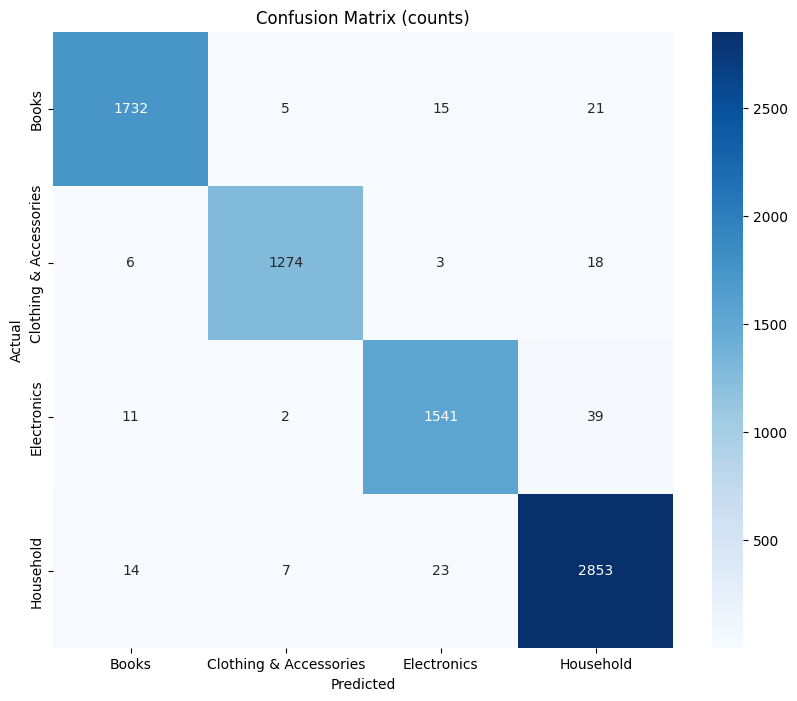

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (counts)")
plt.show()

**Test with new Data**

In [ ]:
new_texts = [
    "An inspiring novel that tells the story of courage and friendship. Paperback edition with 300 pages, ideal for book lovers and students.",
    "Men’s cotton T-shirt with round neck and printed design. Soft breathable fabric perfect for summer wear and available in multiple sizes.",
    "Wireless Bluetooth earbuds with noise cancellation and 20 hours battery backup. Compatible with Android and iOS devices.",
    "Decorative wall clock with modern design and silent sweep movement. Perfect for living room or office decor."
]

sequences = tokenizer.texts_to_sequences(new_texts)
padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

predictions = model.predict(padded)
predicted_classes = np.argmax(predictions, axis=1)

predicted_labels = le.inverse_transform(predicted_classes)

for text, label in zip(new_texts, predicted_labels):
    print("🔹 Text:", text[:80] + "...")
    print("➡️ Predicted label:", label)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
🔹 Text: An inspiring novel that tells the story of courage and friendship. Paperback edi...
➡️ Predicted label: Books

🔹 Text: Men’s cotton T-shirt with round neck and printed design. Soft breathable fabric ...
➡️ Predicted label: Clothing & Accessories

🔹 Text: Wireless Bluetooth earbuds with noise cancellation and 20 hours battery backup. ...
➡️ Predicted label: Electronics

🔹 Text: Decorative wall clock with modern design and silent sweep movement. Perfect for ...
➡️ Predicted label: Household

